### CW08-12.1    More hints

In [65]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from sympy.plotting import plot
from sympy import oo,pi,I, factorial, sqrt, exp, S, assoc_laguerre, Float,Rational
from sympy.utilities.lambdify import lambdify,lambdastr
#from sympy.functions.special.spherical_harmonics import Ynm
from scipy.constants import physical_constants
from scipy.optimize import minimize
sym.init_printing()



# just to be pretty 
from matplotlib import cm
from matplotlib import rc

rc('text', usetex=True)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=16) 
rc('ytick', labelsize=16) 
rc('axes', labelsize=20) 
rc('axes.spines', **{'right':False, 'top':False})

from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
%matplotlib inline

In [66]:
r=sym.Symbol("r", real=True, positive=True)
rho=sym.Symbol("rho", real=True, positive=True)
rhat=sym.Symbol("R", real=True, positive=True)
zeta=sym.Symbol("zeta", positive=True, nonzero=True)

In [67]:
econv = physical_constants['Hartree energy in eV'][0]
econv

27.211386245981

In [68]:
lconv = (1e10)*physical_constants['atomic unit of length'][0]
lconv

0.529177210544

### Define Integrals symbolically

In [69]:
s = (1 + rhat + (rhat**2)/3)*sym.exp(-rhat)
s

⎛ 2        ⎞    
⎜R         ⎟  -R
⎜── + R + 1⎟⋅ℯ  
⎝3         ⎠    

In [70]:
taa = (zeta**2)/2
taa

 2
ζ 
──
2 

In [71]:
tab = ((zeta**2)/2)*(1 + rhat - (rhat**2)/3)*sym.exp(-rhat)
tab

   ⎛   2        ⎞    
 2 ⎜  R         ⎟  -R
ζ ⋅⎜- ── + R + 1⎟⋅ℯ  
   ⎝  3         ⎠    
─────────────────────
          2          

In [72]:
vaaa = -zeta
vaaa

-ζ

In [73]:
vaab = -(zeta/rhat)*(1-(1+rhat)*sym.exp(-2*rhat))
vaab

   ⎛           -2⋅R    ⎞ 
-ζ⋅⎝- (R + 1)⋅ℯ     + 1⎠ 
─────────────────────────
            R            

In [74]:
vaba =  -zeta*(1+rhat)*sym.exp(-rhat)
vaba

            -R
-ζ⋅(R + 1)⋅ℯ  

In [75]:
eelg = (taa + tab + vaaa + vaab + 2*vaba)/(1+s)
eelg

   ⎛   2        ⎞                                                         
 2 ⎜  R         ⎟  -R                                                     
ζ ⋅⎜- ── + R + 1⎟⋅ℯ      2                           ⎛           -2⋅R    ⎞
   ⎝  3         ⎠       ζ                 -R       ζ⋅⎝- (R + 1)⋅ℯ     + 1⎠
───────────────────── + ── - 2⋅ζ⋅(R + 1)⋅ℯ   - ζ - ───────────────────────
          2             2                                     R           
──────────────────────────────────────────────────────────────────────────
                           ⎛ 2        ⎞                                   
                           ⎜R         ⎟  -R                               
                           ⎜── + R + 1⎟⋅ℯ   + 1                           
                           ⎝3         ⎠                                   

In [76]:
eg = eelg + zeta/rhat + Rational(1,2)

In [77]:
eg

       ⎛   2        ⎞                                                          ↪
     2 ⎜  R         ⎟  -R                                                      ↪
    ζ ⋅⎜- ── + R + 1⎟⋅ℯ      2                           ⎛           -2⋅R    ⎞ ↪
       ⎝  3         ⎠       ζ                 -R       ζ⋅⎝- (R + 1)⋅ℯ     + 1⎠ ↪
    ───────────────────── + ── - 2⋅ζ⋅(R + 1)⋅ℯ   - ζ - ─────────────────────── ↪
1             2             2                                     R            ↪
─ + ────────────────────────────────────────────────────────────────────────── ↪
2                              ⎛ 2        ⎞                                    ↪
                               ⎜R         ⎟  -R                                ↪
                               ⎜── + R + 1⎟⋅ℯ   + 1                            ↪
                               ⎝3         ⎠                                    ↪

↪     
↪     
↪     
↪     
↪     
↪    ζ
↪  + ─
↪    R
↪     
↪     
↪     

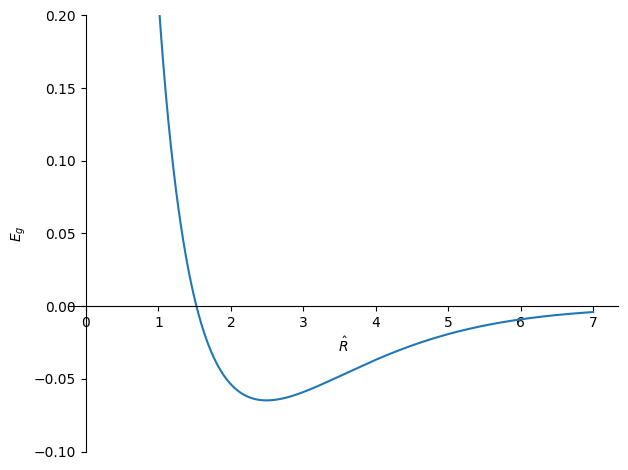

In [78]:
plt.rcParams.update(plt.rcParamsDefault)

plot(eg.subs(zeta,1),(rhat,0.1,7), axis_center=(0,0), ylim = (-.1,0.2),xlabel="$\hat{R}$",ylabel="$E_g$")
plt.show()

In [79]:
eelu = (taa - tab + vaaa + vaab - 2*vaba)/(1-s)

In [80]:
eu = eelu + zeta/rhat + Rational(1,2)

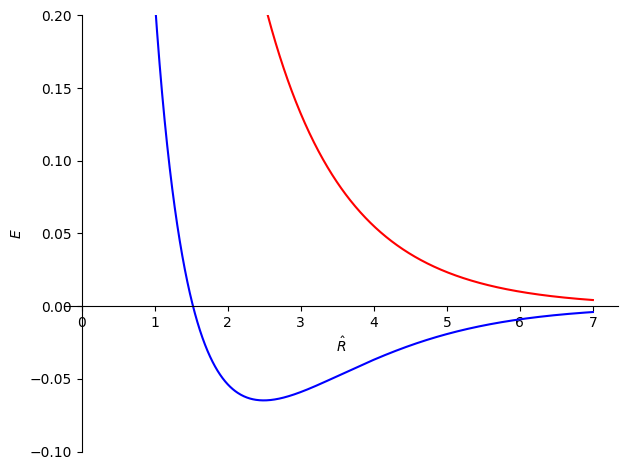

In [81]:
p1 = plot(eg.subs(zeta,1),(rhat,0.1,7), axis_center=(0,0),line_color="blue", ylim = (-.1,0.2),show=False,xlabel="$\hat{R}$",ylabel="$E$")
p2 = plot(eu.subs(zeta,1),(rhat,0.1,7), axis_center=(0,0),line_color="red",show=False)
p1.extend(p2)
p1.show()

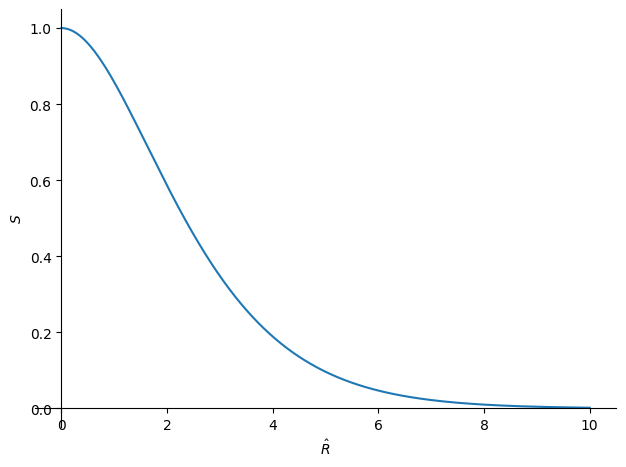

In [82]:
plot(s,(rhat,0.001,10),axis_center=(0,0),xlabel="$\hat{R}$",ylabel="$S$")
plt.show()

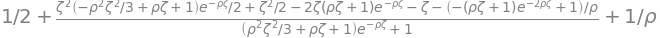

In [83]:
egr = eg.subs(rhat,zeta*rho)
egr

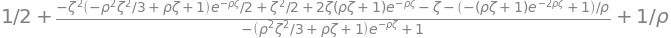

In [84]:
eur = eu.subs(rhat,zeta*rho)
eur

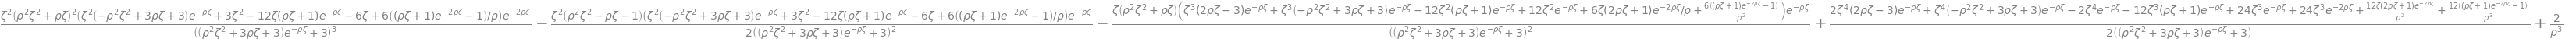

In [85]:
ddegr = sym.diff(egr,rho,2)
ddegr

#### Plot optimized $\zeta$ as a function of R

In [86]:
fego = lambdify([zeta,rho],egr,modules=['numpy'])
feuo = lambdify([zeta,rho],eur,modules=['numpy'])  # for later plot of E(R)
fddego = lambdify([zeta,rho],ddegr,modules=['numpy']) # for later vib freq calc

In [87]:
def zo(r):
    smin = minimize(fego,[1.5],(r))
    return(smin.x[0])

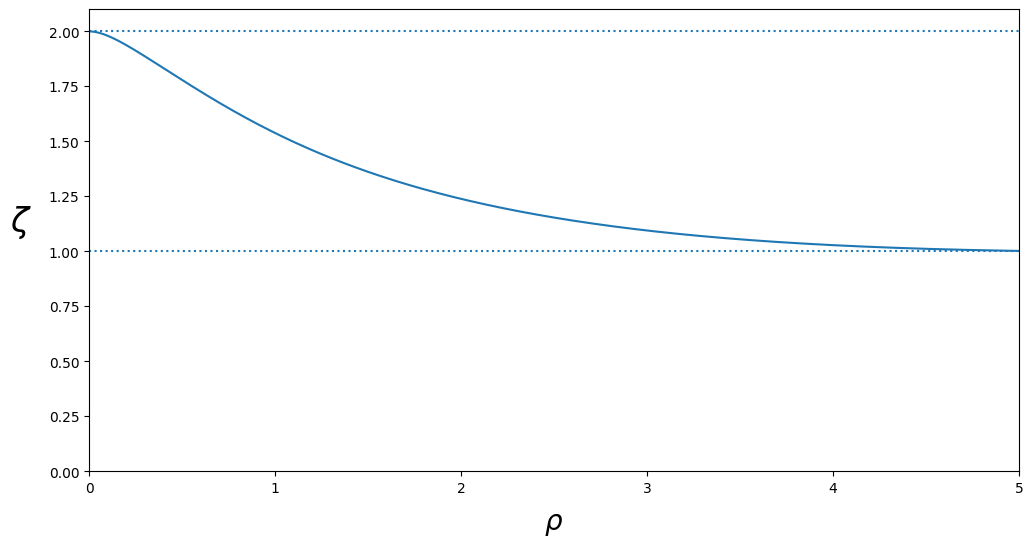

In [88]:
xlow=0.001
xhigh=5
ylow = 0.0
yhigh = 2.1
x1 = np.linspace(xlow,xhigh,1000)
y1 = []
for x in x1:
    y1 += [zo(x)]
fig,ax = plt.subplots(figsize=(12,6))
plt.plot(x1,y1)
plt.xlim(0,xhigh)
plt.ylim(ylow,yhigh)
plt.hlines(1.0,xlow,xhigh,linestyle="dotted")
plt.hlines(2.0,xlow,xhigh,linestyle="dotted")
plt.xlabel(r'$\rho$',fontsize=20,labelpad=10)
plt.ylabel(r'$\zeta$',fontsize=24, rotation=0, labelpad=20)
# plt.title(r'\rm Variationally-optimized $\zeta$ for $H_2^+$',fontsize=28)
#plt.savefig("H2p_zetaVrho.pdf",bbox_inches="tight")
plt.show()

####  Now to plot the static and $\zeta$ optimized Energies

In [89]:
def feg1(r):
    return(fego(1,r)) 
def feu1(r):
    return(feuo(1,r))
def fddeg1(r):
    return(fddego(1,r))

In [90]:
smin = minimize(feg1,[2.5])
sx = smin.x[0]
sy = smin.fun
sx

In [91]:
smin

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.0648309923269364
        x: [ 2.493e+00]
      nit: 2
      jac: [-2.336e-06]
 hess_inv: [[ 1.612e+01]]
     nfev: 8
     njev: 4

In [92]:
print("bond length",sx*lconv,"  Angstroms")

bond length 1.3191292683207891   Angstroms


In [93]:
print("bond dis energy",-sy*econv,"  eV")

bond dis energy 1.7641411729184968   eV


In [94]:
keq = fddeg1(sx)
keq

In [95]:
sec = 2.418884326505e-17
cee = 2.99792458e10
mu = 1836.15267343/2.0   # reduced mass of 1^H_2 in au
freq = (1.0/(2.0*np.pi))*np.sqrt(keq/mu)
print("frequency in atomic units = %10.5e"%freq)
nu = freq/sec
print("frequency in Hz = %10.5e"%nu)
wnum = nu/cee
print("vibrational frequency = %8.2f wavenumbers"%wnum)

frequency in atomic units = 1.31672e-03
frequency in Hz = 5.44348e+13
vibrational frequency =  1815.75 wavenumbers


In [96]:
def fegoz(r):
    return(fego(zo(r),r)) 

In [97]:
omin = minimize(fegoz,[2.0])
ox = omin.x[0]
oy = omin.fun

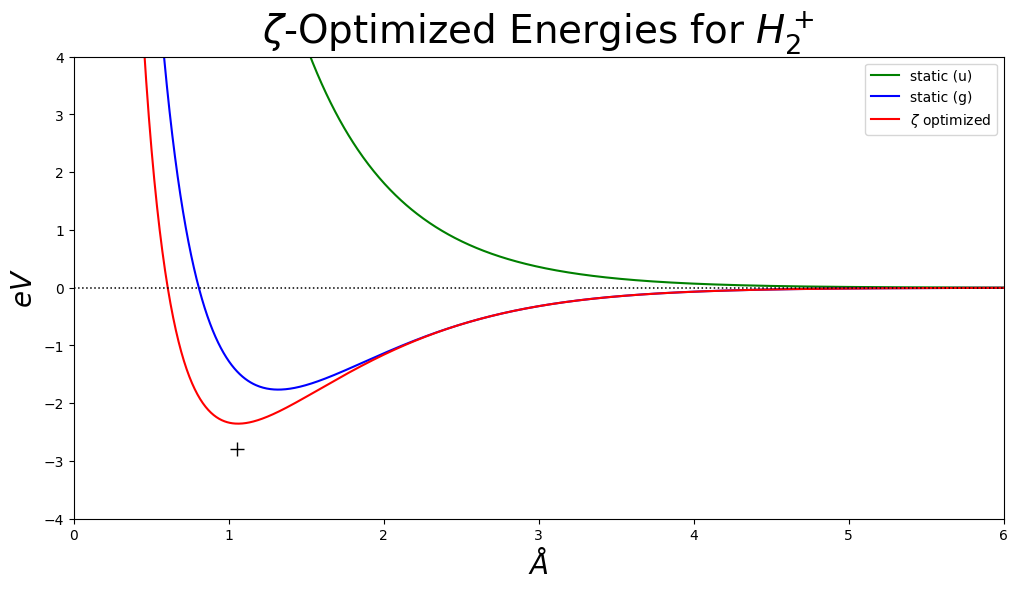

In [ ]:
xlow=0
xhigh=6
ylow = -4.0
yhigh = 4.0
x2 = np.linspace(0.2,xhigh,1000)
y2 = []
y3 = []
y4 = []
for x in x2:
    y2 += [feg1(x*1.88973)*27.2114]
    y3 += [fegoz(x*1.88973)*27.2114]
    y4 += [feu1(x*1.88973)*27.2114]
plt.figure(figsize=(12,6))
plt.plot(x2,y4,color="green",label='static (u)')
plt.plot(x2,y2,color="blue",label='static (g)')
plt.plot(x2,y3,color="red",label=r'$\zeta$ optimized')
plt.xlim(0,xhigh)
plt.ylim(ylow,yhigh)
plt.hlines(0,0,xhigh,linestyle="dotted",linewidth=1.1,color="black")
plt.plot([1.052],[-2.788], marker='+', markersize=10, color='black')
plt.legend()
plt.xlabel(r'$\AA$',fontsize=20)
plt.ylabel(r'$eV$',fontsize=20)
plt.title(r'$\zeta$-Optimized Energies for $H_2^+$',fontsize=28)
plt.show()

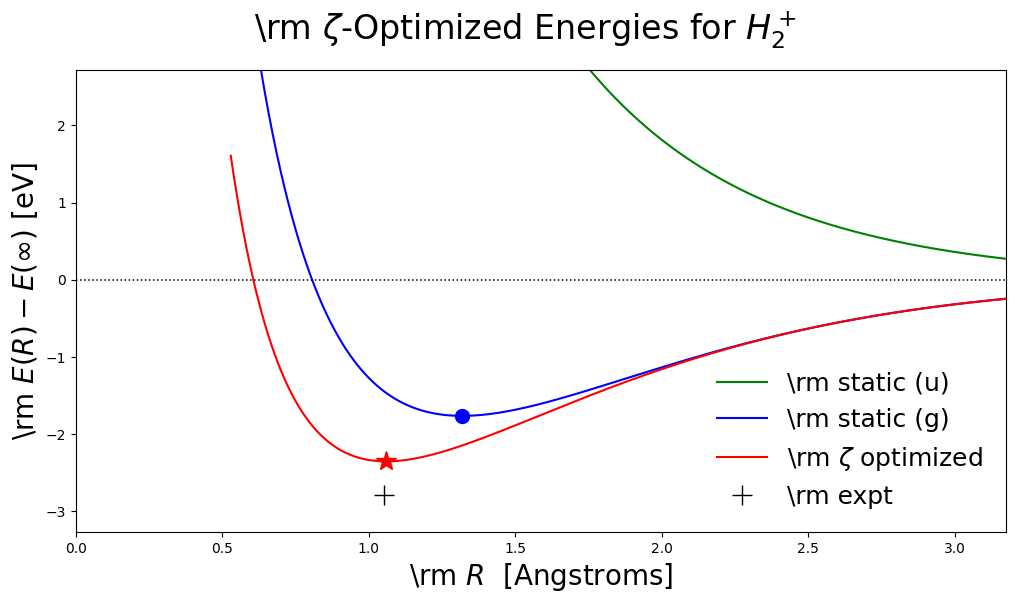

In [99]:
escale = econv
rscale = lconv
xlow=0*rscale
xhigh=6*rscale
ylow = -0.12*escale
yhigh = 0.1*escale
x2 = np.linspace(1.0*rscale,xhigh,1000)
y2 = []
y3 = []
y4 = []
for x in x2:
    y2 += [escale*feg1(x/rscale)]
    y3 += [escale*fegoz(x/rscale)]
    y4 += [escale*feu1(x/rscale)]
plt.figure(figsize=(12,6))
plt.plot(x2,y4,color="green",label=r'\rm static (u)')
plt.plot(x2,y2,color="blue",label=r'\rm static (g)')
plt.plot(x2,y3,color="red",label=r'\rm $\zeta$ optimized')
plt.xlim(0,xhigh)
plt.ylim(ylow,yhigh)
plt.hlines(0,0*escale,xhigh,linestyle="dotted",linewidth=1.1,color="black")
plt.plot((1.052/lconv)*rscale,(-2.788/econv)*escale,'+',markersize=15,\
         linewidth=4,color="black",label=r'\rm expt')
plt.plot(rscale*ox,escale*oy,'*',markersize=15,linewidth=4,color="red")
plt.plot(rscale*sx,escale*sy,'o',markersize=10,linewidth=2,color="blue")
plt.legend(frameon=False,fontsize=18)
plt.xlabel(r'\rm $R$  [Angstroms]',fontsize=20)
plt.ylabel(r'\rm $E(R) - E(\infty)$ [eV]',fontsize=20)
plt.suptitle(r'\rm $\zeta$-Optimized Energies for $H_2^+$',fontsize=24)
plt.show()